# Task 2 (v2): Text Chunking, Embedding & Vector Store

**Project:** Intelligent Complaint Analysis for Financial Services — CrediTrust Financial  
**Input:** `data/processed/filtered_complaints.csv` (output of Task 1)  
**Output:** ChromaDB vector store persisted at `data/vectorstore/`

### Key design decisions (v2)
| Decision | Reason |
|---|---|
| Token-based chunking (not word-based) | Word count is only an approximation — actual tokenizer prevents silent truncation |
| Chunk only if narrative exceeds token limit | 80% of complaints fit in one chunk — unnecessary splitting fragments coherent context |
| Stratified sample (50k complaints, 10k/category) | Balances categories, reduces embedding time from ~13hrs to ~2hrs on CPU |
| Deduplication before embedding | CFPB contains near-duplicate re-submissions — wastes compute and biases retrieval |
| Validate retrieval on small batch first | Confirm chunking + embedding quality before committing to full ingestion |

---

## Notebook Structure
| # | Section |
|---|---|
| 1 | Setup & Imports |
| 2 | Load & Stratified Sample |
| 3 | Deduplication |
| 4 | Token-Based Chunking Strategy |
| 5 | Chunk All Sampled Narratives |
| 6 | Chunking Statistics & Validation |
| 7 | Retrieval Validation on Small Batch (before full ingestion) |
| 8 | Full ChromaDB Ingestion |
| 9 | Retrieval Sanity Check |
| 10 | Vector Store Summary |

---
## 1. Setup & Imports

```bash
pip install sentence-transformers chromadb pandas numpy matplotlib seaborn tqdm
```

In [1]:

# ── Standard library ──────────────────────────────────────────────────────────
import os
import time
import uuid
import warnings
warnings.filterwarnings('ignore')

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Embedding model + tokenizer ───────────────────────────────────────────────
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer

# ── Vector store ──────────────────────────────────────────────────────────────
import chromadb
from chromadb.config import Settings

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print('✅ Imports OK')
import chromadb, sentence_transformers
print(f'   chromadb             : {chromadb.__version__}')
print(f'   sentence-transformers: {sentence_transformers.__version__}')

✅ Imports OK
   chromadb             : 1.5.9
   sentence-transformers: 5.5.0


In [4]:
# ── Relative paths ────────────────────────────────────────────────────────────
BASE_DIR        = os.path.dirname(os.getcwd())  # Go up one level from Notebooks/ to project root
INPUT_PATH      = os.path.join(BASE_DIR, 'data', 'processed', 'filtered_complaints.csv')
VECTORSTORE_DIR = os.path.join(BASE_DIR, 'data', 'vectorstore')
PLOTS_DIR       = os.path.join(BASE_DIR, 'plots')

os.makedirs(VECTORSTORE_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,       exist_ok=True)

# ── Model config ──────────────────────────────────────────────────────────────
EMBEDDING_MODEL   = 'all-MiniLM-L6-v2'
MODEL_TOKEN_LIMIT = 256          # hard limit for all-MiniLM-L6-v2
CHUNK_TOKEN_SIZE  = 200          # target tokens per chunk (56-token safety margin)
CHUNK_TOKEN_OVERLAP = 30         # token overlap between consecutive chunks

# ── Sampling config ───────────────────────────────────────────────────────────
SAMPLE_PER_CATEGORY = 10_000     # 10k per category = 50k total
RANDOM_SEED         = 42

# ── ChromaDB config ───────────────────────────────────────────────────────────
COLLECTION_NAME = 'cfpb_complaints'
BATCH_SIZE      = 512

print(f'Input          : {INPUT_PATH}')
print(f'Vector store   : {VECTORSTORE_DIR}')
print(f'Token limit    : {MODEL_TOKEN_LIMIT} | Chunk size: {CHUNK_TOKEN_SIZE} | Overlap: {CHUNK_TOKEN_OVERLAP}')
print(f'Sample size    : {SAMPLE_PER_CATEGORY:,} per category = {SAMPLE_PER_CATEGORY * 5:,} total')

Input          : c:\Users\Antifragile\Desktop\Credit Trust Complaint chatbot\data\processed\filtered_complaints.csv
Vector store   : c:\Users\Antifragile\Desktop\Credit Trust Complaint chatbot\data\vectorstore
Token limit    : 256 | Chunk size: 200 | Overlap: 30
Sample size    : 10,000 per category = 50,000 total


---
## 2. Load & Stratified Sample

**Why stratified sampling?**
- Credit card has 183k complaints vs Savings account 12k — a 15:1 ratio
- Without balancing, retrieval is dominated by credit card complaints regardless of query
- 10k per category gives equal semantic coverage across all 5 products
- The full 347k dataset is preserved on disk — we sample only for the vector store

> ⚠️ For Savings account (11,971 total), we take all available rows since it is below the 10k target.

In [5]:
# ── Load full filtered dataset ────────────────────────────────────────────────
df_full = pd.read_csv(INPUT_PATH, low_memory=False)
df_full['cleaned_narrative'] = df_full['cleaned_narrative'].fillna('').astype(str)
df_full = df_full[df_full['cleaned_narrative'].str.strip() != ''].reset_index(drop=True)

print(f'Full dataset: {len(df_full):,} complaints')
print('\nFull distribution:')
print(df_full['Product_Category'].value_counts().to_string())

Full dataset: 347,505 complaints

Full distribution:
Product_Category
Credit card          183773
Money transfers       95995
Personal loan         35006
Buy Now Pay Later     20760
Savings account       11971


In [6]:
# ── Stratified sample ─────────────────────────────────────────────────────────
sampled_frames = []

for category, group in df_full.groupby('Product_Category'):
    n = min(SAMPLE_PER_CATEGORY, len(group))   # take all if category < 10k
    sample = group.sample(n=n, random_state=RANDOM_SEED)
    sampled_frames.append(sample)
    print(f'  {category:<25}: sampled {n:,} / {len(group):,}')

df = pd.concat(sampled_frames, ignore_index=True)
print(f'\n✅ Stratified sample: {len(df):,} complaints')
print('\nSampled distribution:')
print(df['Product_Category'].value_counts().to_string())

  Buy Now Pay Later        : sampled 10,000 / 20,760
  Credit card              : sampled 10,000 / 183,773
  Money transfers          : sampled 10,000 / 95,995
  Personal loan            : sampled 10,000 / 35,006
  Savings account          : sampled 10,000 / 11,971

✅ Stratified sample: 50,000 complaints

Sampled distribution:
Product_Category
Buy Now Pay Later    10000
Credit card          10000
Money transfers      10000
Personal loan        10000
Savings account      10000


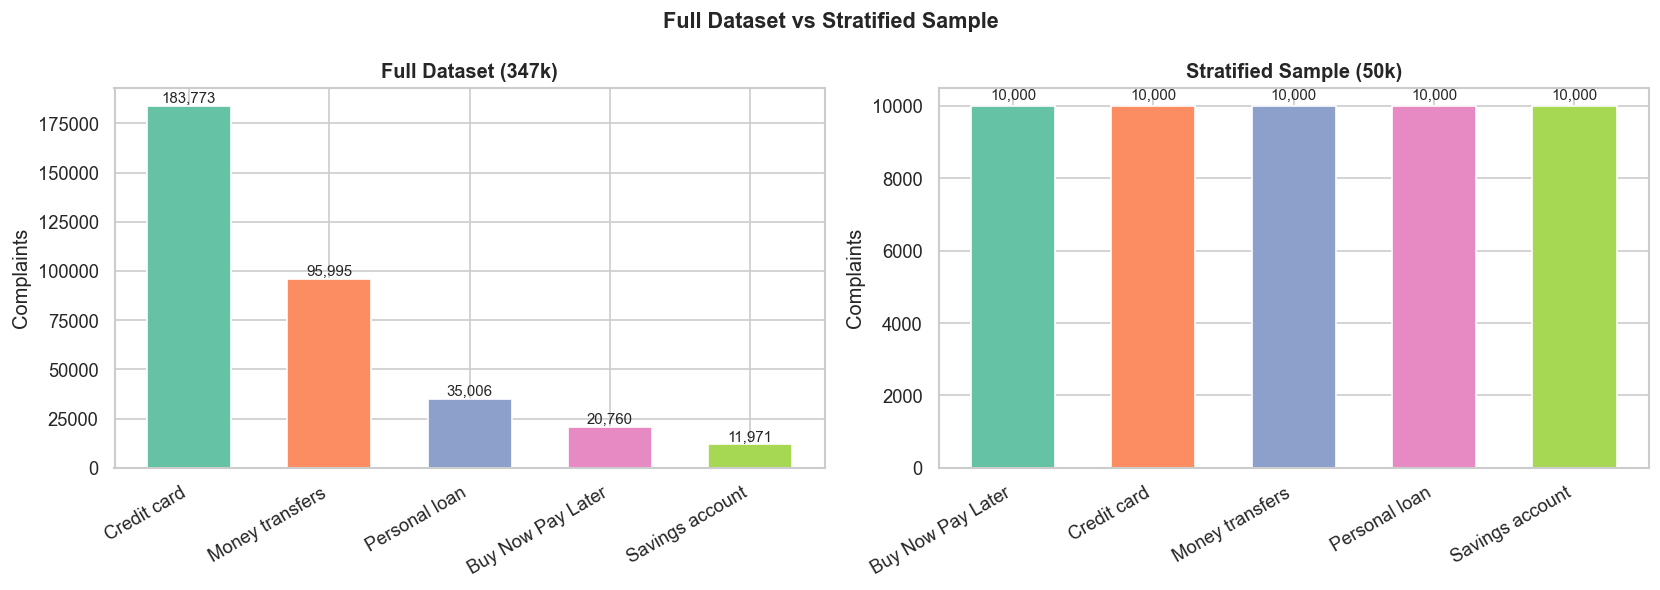

In [7]:
# ── Visualise: full vs sampled distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('Set2', 5)

for ax, data, title in zip(
    axes,
    [df_full['Product_Category'].value_counts(),
     df['Product_Category'].value_counts()],
    ['Full Dataset (347k)', 'Stratified Sample (50k)']
):
    bars = ax.bar(range(len(data)), data.values, color=palette, edgecolor='white', width=0.6)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Complaints')
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data.index, rotation=30, ha='right')
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 100,
                f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Full Dataset vs Stratified Sample', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '07_full_vs_sampled.png'), bbox_inches='tight')
plt.show()

---
## 3. Deduplication

CFPB contains near-duplicate complaints where the same consumer re-submits the same complaint.  
Embedding duplicates wastes compute and biases retrieval toward repeated content.

**Strategy:** Exact deduplication on `cleaned_narrative`. Near-duplicate detection (e.g. MinHash LSH) is out of scope for this project but documented as a known limitation.

In [8]:
# ── Exact deduplication on cleaned narrative ──────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset='cleaned_narrative', keep='first').reset_index(drop=True)
removed = before - len(df)

print(f'Before deduplication : {before:,}')
print(f'Exact duplicates removed: {removed:,} ({removed/before*100:.2f}%)')
print(f'After deduplication  : {len(df):,}')

if removed == 0:
    print('\n✅ No exact duplicates found in stratified sample.')
else:
    print('\n✅ Duplicates removed. Proceeding with clean corpus.')

print('\n⚠️  Note: Near-duplicate detection (MinHash LSH) is a known limitation.')
print('   Consumers sometimes re-submit slightly modified versions of the same complaint.')

Before deduplication : 50,000
Exact duplicates removed: 4,708 (9.42%)
After deduplication  : 45,292

✅ Duplicates removed. Proceeding with clean corpus.

⚠️  Note: Near-duplicate detection (MinHash LSH) is a known limitation.
   Consumers sometimes re-submit slightly modified versions of the same complaint.


---
## 4. Token-Based Chunking Strategy

### Why token-based and not word-based?

The previous approach used word count as a proxy for token count.  
This is **inaccurate** for financial/legal text:

| Text type | Words | Tokens | Ratio |
|---|---|---|---|
| Plain English | 100 | ~130 | 1.3x |
| Financial/legal complaint | 100 | ~140–160 | 1.4–1.6x |
| With numbers, dates, punctuation | 100 | ~170+ | 1.7x+ |

300 words of complaint text → **420–510 tokens** — almost **2x the model limit**.  
The tokenizer is the only accurate measure. We use it directly.

### Adaptive chunking logic
```
if token_count <= CHUNK_TOKEN_SIZE (200):
    → store as single chunk — no splitting needed
else:
    → split into 200-token windows with 30-token overlap
```
This avoids fragmenting the 80% of complaints that are already short and coherent.

In [9]:
# ── Load tokenizer (same model as embedder — must match) ─────────────────────
print(f'Loading tokenizer for: {EMBEDDING_MODEL}')
tokenizer = AutoTokenizer.from_pretrained(f'sentence-transformers/{EMBEDDING_MODEL}')
print(f'✅ Tokenizer loaded. Vocab size: {tokenizer.vocab_size:,}')

# ── Token count accuracy check ────────────────────────────────────────────────
# Show why word-count heuristics fail on complaint text
sample_texts = df['cleaned_narrative'].head(5).tolist()
print('\n=== Word count vs actual token count (5 samples) ===')
print(f'{"Words":>8} {"Tokens":>8} {"Ratio":>8}')
for text in sample_texts:
    words  = len(text.split())
    tokens = len(tokenizer.encode(text, add_special_tokens=False))
    print(f'{words:>8} {tokens:>8} {tokens/words:>8.2f}x')

Loading tokenizer for: all-MiniLM-L6-v2


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (651 > 512). Running this sequence through the model will result in indexing errors


✅ Tokenizer loaded. Vocab size: 30,522

=== Word count vs actual token count (5 samples) ===
   Words   Tokens    Ratio
     236      292     1.24x
     516      651     1.26x
     234      301     1.29x
     254      294     1.16x
     542      662     1.22x


In [10]:
def chunk_by_tokens(text: str, tokenizer, 
                    chunk_size: int = CHUNK_TOKEN_SIZE,
                    overlap: int = CHUNK_TOKEN_OVERLAP) -> list[str]:
    """
    Split text into overlapping token-based chunks using the actual model tokenizer.

    Logic:
        - If text fits within chunk_size tokens → return as single chunk (no split)
        - Otherwise → sliding window over token IDs, decode each window back to text

    Args:
        text       : cleaned narrative string
        tokenizer  : HuggingFace tokenizer matching the embedding model
        chunk_size : max tokens per chunk (default: 200, safely under 256 limit)
        overlap    : token overlap between consecutive chunks (default: 30)

    Returns:
        List of decoded text chunks. Always returns at least one chunk.
    """
    if not isinstance(text, str) or not text.strip():
        return []

    # Tokenize without special tokens (we manage boundaries ourselves)
    token_ids = tokenizer.encode(text, add_special_tokens=False)

    # Short text — no splitting needed
    if len(token_ids) <= chunk_size:
        return [text]

    # Sliding window over token IDs
    chunks = []
    step   = chunk_size - overlap
    start  = 0

    while start < len(token_ids):
        end        = start + chunk_size
        chunk_ids  = token_ids[start:end]
        chunk_text = tokenizer.decode(chunk_ids, skip_special_tokens=True)
        chunks.append(chunk_text)
        if end >= len(token_ids):
            break
        start += step

    return chunks


# ── Unit test ─────────────────────────────────────────────────────────────────
test_text  = df['cleaned_narrative'].iloc[0]
test_chunks = chunk_by_tokens(test_text, tokenizer)

print(f'Unit test narrative: {len(tokenizer.encode(test_text, add_special_tokens=False))} tokens')
print(f'Produced {len(test_chunks)} chunk(s)')
for i, c in enumerate(test_chunks):
    token_len = len(tokenizer.encode(c, add_special_tokens=False))
    print(f'  Chunk {i+1}: {token_len} tokens (limit: {MODEL_TOKEN_LIMIT})')
    assert token_len <= MODEL_TOKEN_LIMIT, f'❌ Chunk {i+1} exceeds token limit!'
print('✅ All chunks within token limit')

Unit test narrative: 292 tokens
Produced 2 chunk(s)
  Chunk 1: 200 tokens (limit: 256)
  Chunk 2: 122 tokens (limit: 256)
✅ All chunks within token limit


---
## 5. Chunk All Sampled Narratives

In [11]:
# ── Chunk every narrative ─────────────────────────────────────────────────────
chunk_records = []

print('Chunking narratives (token-based, adaptive)...')

for _, row in tqdm(df.iterrows(), total=len(df), desc='Chunking'):

    chunks = chunk_by_tokens(row['cleaned_narrative'], tokenizer)

    for chunk_idx, chunk_text in enumerate(chunks):
        chunk_records.append({
            'chunk_id'         : f"{row.get('Complaint ID', uuid.uuid4())}_{chunk_idx}",
            'text'             : chunk_text,
            'complaint_id'     : str(row.get('Complaint ID', '')),
            'product_category' : str(row.get('Product_Category', '')),
            'product_original' : str(row.get('Product', '')),
            'issue'            : str(row.get('Issue', ''))[:500],
            'company'          : str(row.get('Company', ''))[:200],
            'state'            : str(row.get('State', '')),
            'date_received'    : str(row.get('Date received', '')),
            'company_response' : str(row.get('Company response to consumer', '')),
            'timely_response'  : str(row.get('Timely response?', '')),
            'chunk_index'      : chunk_idx,
            'total_chunks'     : len(chunks),
            'was_split'        : len(chunks) > 1,    # flag for analysis
        })

df_chunks = pd.DataFrame(chunk_records)

print(f'\n✅ Chunking complete.')
print(f'   Total complaints : {len(df):,}')
print(f'   Total chunks     : {len(df_chunks):,}')
print(f'   Avg chunks/complaint: {len(df_chunks)/len(df):.3f}')
print(f'   Complaints NOT split: {(df_chunks["total_chunks"] == 1)["total_chunks"].sum() if False else df_chunks.groupby("complaint_id")["was_split"].first().eq(False).sum():,}')
print(f'   Complaints split    : {df_chunks.groupby("complaint_id")["was_split"].first().eq(True).sum():,}')

Chunking narratives (token-based, adaptive)...


Chunking: 100%|██████████| 45292/45292 [03:07<00:00, 241.32it/s]



✅ Chunking complete.
   Total complaints : 45,292
   Total chunks     : 100,483
   Avg chunks/complaint: 2.219
   Complaints NOT split: 23,012
   Complaints split    : 22,280


---
## 6. Chunking Statistics & Validation

In [12]:
# ── Verify NO chunk exceeds the model token limit ────────────────────────────
print('Verifying all chunks are within token limit...')
token_counts = [
    len(tokenizer.encode(text, add_special_tokens=False))
    for text in tqdm(df_chunks['text'].tolist(), desc='Token counting')
]
df_chunks['token_count'] = token_counts

violations = (df_chunks['token_count'] > MODEL_TOKEN_LIMIT).sum()
print(f'\nChunks exceeding {MODEL_TOKEN_LIMIT} token limit: {violations}')
assert violations == 0, f'❌ {violations} chunks exceed token limit!'
print('✅ All chunks within token limit.')
print(f'\nToken count stats:')
print(df_chunks['token_count'].describe().round(1).to_string())

Verifying all chunks are within token limit...


Token counting: 100%|██████████| 100483/100483 [02:27<00:00, 680.48it/s] 



Chunks exceeding 256 token limit: 0
✅ All chunks within token limit.

Token count stats:
count    100483.0
mean        158.0
std          56.5
min          20.0
25%         113.0
50%         200.0
75%         200.0
max         204.0


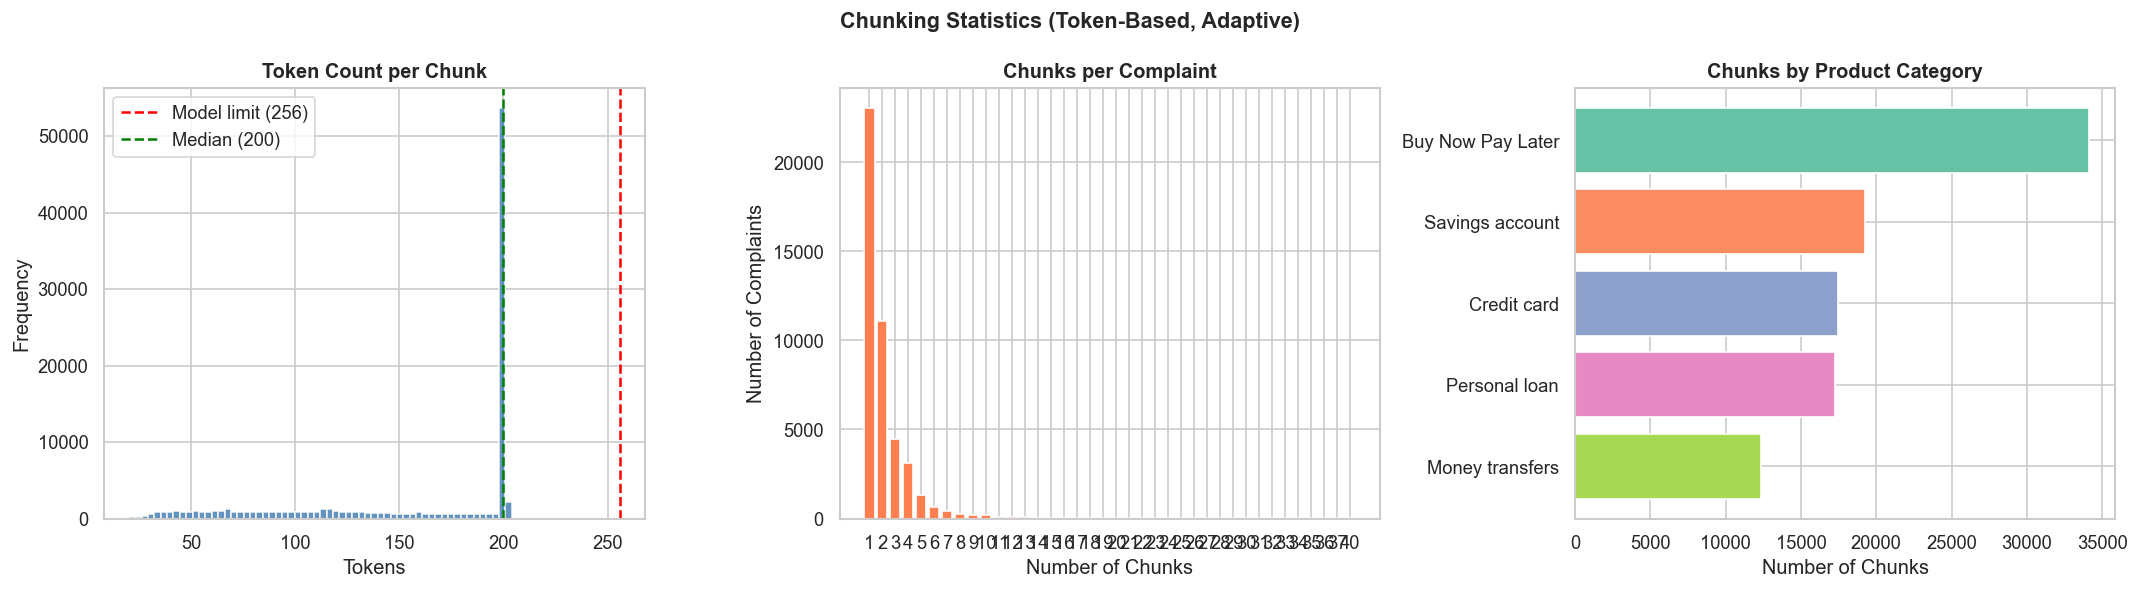

Split rate: 77.1% of complaints were split into multiple chunks


In [13]:
# ── Chunking statistics plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Token count distribution per chunk
axes[0].hist(df_chunks['token_count'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(MODEL_TOKEN_LIMIT, color='red', linestyle='--', lw=1.5, label=f'Model limit ({MODEL_TOKEN_LIMIT})')
axes[0].axvline(df_chunks['token_count'].median(), color='green', linestyle='--', lw=1.5,
                label=f'Median ({df_chunks["token_count"].median():.0f})')
axes[0].set_title('Token Count per Chunk', fontweight='bold')
axes[0].set_xlabel('Tokens')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Chunks per complaint
chunks_per = df_chunks.groupby('complaint_id').size().value_counts().sort_index()
axes[1].bar(chunks_per.index.astype(str), chunks_per.values,
            color='coral', edgecolor='white')
axes[1].set_title('Chunks per Complaint', fontweight='bold')
axes[1].set_xlabel('Number of Chunks')
axes[1].set_ylabel('Number of Complaints')

# 3. Chunks by product category
cat_counts = df_chunks['product_category'].value_counts()
palette    = sns.color_palette('Set2', len(cat_counts))
axes[2].barh(range(len(cat_counts)), cat_counts.values, color=palette, edgecolor='white')
axes[2].set_yticks(range(len(cat_counts)))
axes[2].set_yticklabels(cat_counts.index)
axes[2].set_title('Chunks by Product Category', fontweight='bold')
axes[2].set_xlabel('Number of Chunks')
axes[2].invert_yaxis()

plt.suptitle('Chunking Statistics (Token-Based, Adaptive)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '08_chunking_statistics_v2.png'), bbox_inches='tight')
plt.show()

print(f'Split rate: {df_chunks["was_split"].mean()*100:.1f}% of complaints were split into multiple chunks')

---
## 7. Retrieval Validation on Small Batch

**Validate before committing to full ingestion.**  
Embed 500 chunks (100 per category), build a mini vector store, run test queries.  
If retrieval quality is poor here, fix chunking before spending hours embedding everything.

In [14]:
# ── Load embedding model ──────────────────────────────────────────────────────
print(f'Loading embedding model: {EMBEDDING_MODEL}')
embedder = SentenceTransformer(EMBEDDING_MODEL)
print(f'✅ Model loaded. Dimensions: {embedder.get_sentence_embedding_dimension()}')

# ── Build mini validation corpus: 100 chunks per category ────────────────────
VALIDATION_PER_CAT = 100
val_frames = [
    group.head(VALIDATION_PER_CAT)
    for _, group in df_chunks.groupby('product_category')
]
df_val = pd.concat(val_frames, ignore_index=True)
print(f'\nValidation corpus: {len(df_val)} chunks ({VALIDATION_PER_CAT} per category)')

Loading embedding model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1584.59it/s]


✅ Model loaded. Dimensions: 384

Validation corpus: 500 chunks (100 per category)


In [15]:
# ── Build mini ChromaDB for validation ───────────────────────────────────────
val_client     = chromadb.EphemeralClient()   # in-memory only, no disk write
val_collection = val_client.create_collection(
    name='validation',
    metadata={'hnsw:space': 'cosine'}
)

val_texts      = df_val['text'].tolist()
val_ids        = df_val['chunk_id'].tolist()
val_metadatas  = [{k: str(v) for k, v in m.items()}
                  for m in df_val[['product_category', 'company', 'state',
                                   'issue', 'complaint_id']].to_dict(orient='records')]

val_embeddings = embedder.encode(
    val_texts, batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True
).tolist()

val_collection.upsert(
    ids=val_ids, embeddings=val_embeddings,
    documents=val_texts, metadatas=val_metadatas
)
print(f'\n✅ Validation store built: {val_collection.count()} chunks')

Batches: 100%|██████████| 8/8 [00:42<00:00,  5.29s/it]



✅ Validation store built: 500 chunks


In [16]:
# ── Run validation queries ────────────────────────────────────────────────────
VALIDATION_QUERIES = [
    ('unauthorized charge on my credit card',            'Credit card'),
    ('high interest rate personal loan I cannot repay',  'Personal loan'),
    ('affirm klarna buy now pay later not processed',    'Buy Now Pay Later'),
    ('savings account funds missing no explanation',     'Savings account'),
    ('international wire transfer never arrived',        'Money transfers'),
]

print('=== RETRIEVAL VALIDATION RESULTS ===')
print('Checking: does the top result match the expected product category?\n')

passed = 0
for query, expected_cat in VALIDATION_QUERIES:
    q_emb = embedder.encode([query], normalize_embeddings=True).tolist()

    # Query WITHOUT filter — tests natural retrieval alignment
    results = val_collection.query(
        query_embeddings=q_emb,
        n_results=3,
        include=['documents', 'metadatas', 'distances']
    )

    top_cat  = results['metadatas'][0][0]['product_category']
    top_sim  = round(1 - results['distances'][0][0], 4)
    top_text = results['documents'][0][0][:200]
    match    = '✅' if top_cat == expected_cat else '⚠️ '
    if top_cat == expected_cat:
        passed += 1

    print(f'Query    : "{query}"')
    print(f'Expected : {expected_cat}')
    print(f'Got      : {top_cat} (similarity: {top_sim}) {match}')
    print(f'Preview  : {top_text}...')
    print()

print(f'Validation score: {passed}/{len(VALIDATION_QUERIES)} queries returned expected category as top result')
if passed >= 4:
    print('✅ Retrieval quality validated. Proceeding to full ingestion.')
else:
    print('⚠️  Retrieval quality below threshold. Review chunking strategy before full ingestion.')

=== RETRIEVAL VALIDATION RESULTS ===
Checking: does the top result match the expected product category?

Query    : "unauthorized charge on my credit card"
Expected : Credit card
Got      : Credit card (similarity: 0.7252) ✅
Preview  : summary my credit card citi has authorized to charge me for a service product that i did not authorize, and that did not provide, and will not provide. details several years ago i set up a placeholder...

Query    : "high interest rate personal loan I cannot repay"
Expected : Personal loan
Got      : Personal loan (similarity: 0.5311) ✅
Preview  : purchased a household appliance. the financing was done through synchrony financial, one year interest free. paid much more that the minimum payment. was not able to pay off in the 1 year time frame. ...

Query    : "affirm klarna buy now pay later not processed"
Expected : Buy Now Pay Later
Got      : Buy Now Pay Later (similarity: 0.6244) ✅
Preview  : indicated the account would be updated as paid in full. ho

---
## 8. Full ChromaDB Ingestion

> Only run this cell after validation passes in Section 7.

In [17]:
# ── Initialise persistent ChromaDB client ────────────────────────────────────
client = chromadb.PersistentClient(
    path=VECTORSTORE_DIR,
    settings=Settings(anonymized_telemetry=False)
)

# Clean rebuild — delete if exists
existing = [c.name for c in client.list_collections()]
if COLLECTION_NAME in existing:
    client.delete_collection(COLLECTION_NAME)
    print(f'🗑️  Deleted existing collection: {COLLECTION_NAME}')

collection = client.create_collection(
    name=COLLECTION_NAME,
    metadata={
        'hnsw:space' : 'cosine',
        'description': 'CFPB complaints — 5 categories — token-chunked — stratified 50k sample'
    }
)
print(f'✅ Collection created: "{COLLECTION_NAME}"')

✅ Collection created: "cfpb_complaints"


In [18]:
# ── Embed and ingest all chunks in batches ───────────────────────────────────
texts     = df_chunks['text'].tolist()
chunk_ids = df_chunks['chunk_id'].tolist()
metadatas = [
    {k: str(v) for k, v in m.items()}
    for m in df_chunks[[
        'complaint_id', 'product_category', 'product_original',
        'issue', 'company', 'state', 'date_received',
        'company_response', 'timely_response',
        'chunk_index', 'total_chunks', 'was_split'
    ]].to_dict(orient='records')
]

total     = len(texts)
n_batches = (total + BATCH_SIZE - 1) // BATCH_SIZE

# Estimate time from benchmark
bench_texts = texts[:100]
t0 = time.time()
embedder.encode(bench_texts, batch_size=64, show_progress_bar=False)
bench_rate = 100 / (time.time() - t0)
est_minutes = total / bench_rate / 60
print(f'Benchmark: {bench_rate:.0f} chunks/sec → estimated {est_minutes:.0f} min for {total:,} chunks')
print(f'Ingesting in {n_batches} batches (batch size = {BATCH_SIZE})...\n')

start_time = time.time()

for batch_num in tqdm(range(n_batches), desc='Embedding & ingesting'):
    s = batch_num * BATCH_SIZE
    e = min(s + BATCH_SIZE, total)

    batch_embeddings = embedder.encode(
        texts[s:e],
        batch_size=64,
        normalize_embeddings=True,
        show_progress_bar=False
    ).tolist()

    collection.upsert(
        ids        = chunk_ids[s:e],
        embeddings = batch_embeddings,
        documents  = texts[s:e],
        metadatas  = metadatas[s:e]
    )

elapsed = time.time() - start_time
print(f'\n✅ Ingestion complete.')
print(f'   Chunks ingested: {collection.count():,}')
print(f'   Total time     : {elapsed/60:.1f} minutes')
print(f'   Throughput     : {total/elapsed:.0f} chunks/sec')

Benchmark: 14 chunks/sec → estimated 116 min for 100,483 chunks
Ingesting in 197 batches (batch size = 512)...



Embedding & ingesting: 100%|██████████| 197/197 [2:09:54<00:00, 39.57s/it]  


✅ Ingestion complete.
   Chunks ingested: 100,483
   Total time     : 129.9 minutes
   Throughput     : 13 chunks/sec


---
## 9. Retrieval Sanity Check (Full Store)

In [20]:
# ── Reusable query function ───────────────────────────────────────────────────
def query_store(query: str, product_category: str = None,
                n_results: int = 3) -> pd.DataFrame:
    """
    Query the ChromaDB vector store with optional metadata filter.

    Args:
        query            : natural language question
        product_category : optional filter — restricts results to one category
        n_results        : number of results to return

    Returns:
        DataFrame with similarity score, metadata, and text preview.
    """
    q_emb = embedder.encode([query], normalize_embeddings=True).tolist()
    where = {'product_category': product_category} if product_category else None

    results = collection.query(
        query_embeddings = q_emb,
        n_results        = n_results,
        where            = where,
        include          = ['documents', 'metadatas', 'distances']
    )

    rows = []
    for doc, meta, dist in zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0]
    ):
        rows.append({
            'similarity'       : round(1 - dist, 4),
            'product_category' : meta.get('product_category'),
            'company'          : meta.get('company'),
            'state'            : meta.get('state'),
            'issue'            : meta.get('issue', '')[:80],
            'text_preview'     : doc[:250] + '...' if len(doc) > 250 else doc
        })

    return pd.DataFrame(rows)

In [21]:
# ── Test: filtered queries (one per category) ─────────────────────────────────
TEST_QUERIES = [
    ('unauthorized charge on my credit card',            'Credit card'),
    ('high interest personal loan unable to repay',      'Personal loan'),
    ('klarna affirm buy now pay later payment failed',   'Buy Now Pay Later'),
    ('savings account balance disappeared no notice',    'Savings account'),
    ('wire transfer never arrived recipient waiting',    'Money transfers'),
]

for query, category in TEST_QUERIES:
    print(f'\n{"="*65}')
    print(f'Query  : "{query}"')
    print(f'Filter : {category}')
    print(f'{"="*65}')
    results = query_store(query, product_category=category, n_results=2)
    for i, row in results.iterrows():
        print(f'  [{i+1}] sim={row["similarity"]} | {row["company"]} | {row["state"]}')
        print(f'       {row["text_preview"]}')
        print()


Query  : "unauthorized charge on my credit card"
Filter : Credit card
  [1] sim=0.748 | BANK OF AMERICA, NATIONAL ASSOCIATION | CA
       from 2021 to there was unauthorized charges on my credit card totaling 7300. 00. i did not authorize those charges and no one else is on the credit card account. initially bank of america reversed all the charges, but after there very very short inve...

  [2] sim=0.7442 | GOLDMAN SACHS BANK USA | IL
       , the customer service representative was extremely rude, and did not address the issue. today, i received another unauthorized charge, been this month the 10th time i received a non - authorized charge from the same business, after following the ban...


Query  : "high interest personal loan unable to repay"
Filter : Personal loan
  [1] sim=0.7276 | Bliksum, LLC | CA
       i requested a personal loan to loan me company for , at the time that i requested i have a emergency and i needed the money right away, i was very desperate that at the momen

In [22]:
# ── Test: cross-category query with NO filter ─────────────────────────────────
# Shows which category naturally dominates for a generic fraud query.
print('Cross-category query (no filter): "fraud on my account I did not authorise this"')
print('='*65)
cross = query_store('fraud on my account I did not authorise this', n_results=5)
print(cross[['similarity', 'product_category', 'company', 'text_preview']].to_string())

Cross-category query (no filter): "fraud on my account I did not authorise this"
   similarity product_category                                 company                                                                                                                                                                                                                                                   text_preview
0      0.6970  Savings account   BANK OF AMERICA, NATIONAL ASSOCIATION  checking account had fraud so i was stated to put money and automatic deposit to a savings while they investigated the fraud they determined it was me knowing they have the fraudulent deposits to my account so they forced closed that checking account...
1      0.6868  Savings account          CITIZENS FINANCIAL GROUP, INC.  by me, and i immediately contacted the bank to report the fraudulent activity. the unauthorized transactions have caused financial distress and inconvenience. i am concerned about the security of

In [25]:
# ── Persistence verification ──────────────────────────────────────────────────
reload_client     = chromadb.PersistentClient(
    path=VECTORSTORE_DIR,
    settings=Settings(anonymized_telemetry=False)
)
reload_collection = reload_client.get_collection(COLLECTION_NAME)
assert reload_collection.count() == collection.count(), '❌ Reload count mismatch!'
print(f'✅ Persistence verified — {reload_collection.count():,} chunks reloaded from disk.')

✅ Persistence verified — 100,483 chunks reloaded from disk.


---
## 10. Vector Store Summary

In [24]:
# ── Print final summary ───────────────────────────────────────────────────────
split_count    = df_chunks.groupby('complaint_id')['was_split'].first().sum()
no_split_count = len(df) - split_count

print('╔══════════════════════════════════════════════════════════════╗')
print('║           TASK 2 (v2) — VECTOR STORE SUMMARY                ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Embedding model     : {EMBEDDING_MODEL:<37}║')
print(f'║  Token limit         : {str(MODEL_TOKEN_LIMIT) + " tokens":<37}║')
print(f'║  Chunk size          : {str(CHUNK_TOKEN_SIZE) + " tokens (hard limit enforced)":<37}║')
print(f'║  Chunk overlap       : {str(CHUNK_TOKEN_OVERLAP) + " tokens":<37}║')
print(f'║  Similarity metric   : {"Cosine":<37}║')
print(f'║  Embedding dims      : {"384":<37}║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Full dataset        : {"347,505 complaints":<37}║')
print(f'║  Stratified sample   : {str(len(df)) + " complaints (10k/category)":<37}║')
print(f'║  Deduplication       : {"exact match on cleaned_narrative":<37}║')
print(f'║  Complaints not split: {str(no_split_count) + " (single chunk)":<37}║')
print(f'║  Complaints split    : {str(split_count) + " (multiple chunks)":<37}║')
print(f'║  Total chunks        : {str(collection.count()) + " (all within token limit)":<37}║')
print(f'║  Persisted at        : data/vectorstore/                    ║')
print('╚══════════════════════════════════════════════════════════════╝')

print('\nChunks per product category:')
print(df_chunks['product_category'].value_counts().to_string())
print('\n🎯 Task 2 complete. Ready for Task 3 (RAG pipeline + LLM integration).')

╔══════════════════════════════════════════════════════════════╗
║           TASK 2 (v2) — VECTOR STORE SUMMARY                ║
╠══════════════════════════════════════════════════════════════╣
║  Embedding model     : all-MiniLM-L6-v2                     ║
║  Token limit         : 256 tokens                           ║
║  Chunk size          : 200 tokens (hard limit enforced)     ║
║  Chunk overlap       : 30 tokens                            ║
║  Similarity metric   : Cosine                               ║
║  Embedding dims      : 384                                  ║
╠══════════════════════════════════════════════════════════════╣
║  Full dataset        : 347,505 complaints                   ║
║  Stratified sample   : 45292 complaints (10k/category)      ║
║  Deduplication       : exact match on cleaned_narrative     ║
║  Complaints not split: 23012 (single chunk)                 ║
║  Complaints split    : 22280 (multiple chunks)              ║
║  Total chunks        : 100483 (all 